
<div style="
    background-color: #f7f7f7;
    background-image: url(''), url('') ;
    background-position: left bottom, right top;
    background-repeat: no-repeat,  no-repeat;
    background-size: auto 60px, auto 160px;
    border-radius: 5px;
    box-shadow: 0px 3px 1px -2px rgba(0, 0, 0, 0.2), 0px 2px 2px 0px rgba(0, 0, 0, 0.14), 0px 1px 5px 0px rgba(0,0,0,.12);">

<h1 style="
    color: #2a4cdf;
    font-style: normal;
    font-size: 2.25rem;
    line-height: 1.4em;
    font-weight: 600;
    padding: 30px 200px 0px 30px;"> 
        Perovscribe Evals</h1>

<p style="
    line-height: 1.4em;
    padding: 30px 200px 0px 30px;">
    This notebook runs through the analysis of the Perovscribe extraction pipeline.
</p>

<p style="font-size: 1.25em; font-style: italic; padding: 5px 200px 30px 30px;">
     Sherjeel Shabih, Hampus Näsström, Kevin Jablonka and Pepe Márquez
</p>
</div>

## Setup and Evaluations

### Imports & Setup

In [ ]:
# --- Imports ---
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from math import pi
from importlib.resources import files

# Third-party libraries
from dotenv import load_dotenv
import litellm
from litellm.caching import Cache
import dabest
import plotly.graph_objects as go

# Internal modules
# Ensure 'perovscribe' is accessible in the repo structure
from perovscribe.pipeline import ExtractionPipeline 
from plotly_theme import register_template, set_defaults

# --- Configuration & Theme ---
load_dotenv()  # Loads .env if present
register_template()
set_defaults()

# Define Paths (Use relative paths for reproducibility!)
DATA_DIR = files("perovscribe").joinpath("data")
EXTRACTIONS_DIR = DATA_DIR / "extractions" 
GROUND_TRUTH_DIR = DATA_DIR / "ground_truth" / "test"
EXPERTS_DIR = EXTRACTIONS_DIR / "humans" / "Consensus"

### Optional LLM caching

In [ ]:
# # Setup Caching
# litellm.cache = Cache(
#     type="redis",
#     host="127.0.0.1",
#     port=6379,
#     ttl=1000000,
#     namespace="litellm",
# )

### Model Configurations

In [18]:
# Define model metadata: Display Names, Colors, and Token Costs (per 1M tokens)
# Prices are examples; verify current API pricing.
MODEL_CONFIG = {
    "gpt-5-2025-08-07": {
        "name": "GPT-5",
        "color": "#ff7f0e", # Orange
        "prompt_price": 1.25,
        "output_price": 10.0
    },
    "gpt-5-mini-2025-08-07": {
        "name": "GPT-5 Mini",
        "color": "#1f77b4", # Muted Blue
        "prompt_price": 0.25,
        "output_price": 2.0
    },
    "claude-opus-4-20250514": {
        "name": "Claude Opus 4",
        "color": "#d62728", # Red
        "prompt_price": 15.0,
        "output_price": 75.0
    },
    "claude-sonnet-4-20250514": {
        "name": "Claude Sonnet 4",
        "color": "#9467bd", # Purple
        "prompt_price": 3.0,
        "output_price": 15.0
    },
    "claude-opus-4-1-20250805": {
        "name": "Claude Opus 4.1",
        "color": "#f5a911",
        "prompt_price": 15.0,
        "output_price": 75.0
    },
    "gpt-4.1-2025-04-14": {
        "name": "GPT-4.1",
        "color": "#8c564b", # Brown
        "prompt_price": 2.0,
        "output_price": 8.0
    },
    "gpt-4o-2024-08-06": {
        "name": "GPT-4o",
        "color": "#e377c2", # Pink
        "prompt_price": 2.50,
        "output_price": 10.0
    },
}

## Evaluations

##### Evals Code

In [19]:
# ============================================================================
# DATA LOADING AND MODEL EVALUATION
# ============================================================================

all_metrics = {}  # model_name -> paper_doi -> {field: score}
all_precs_and_recalls = {}

# Evaluate all models
for model_dir in EXTRACTIONS_DIR.iterdir():
    if not model_dir.is_dir() or model_dir == "humans":
        continue
    
    model_name = model_dir.name
    print(f"Evaluating model: {model_name}")
    
    pipeline = ExtractionPipeline(
        model_name=model_name, 
        preprocessor="pymupdf", 
        postprocessor="NONE", 
        cache_dir="", 
        use_cache=True
    )
    model_metrics, avg_recalls, avg_precisions = pipeline._evaluate_multiple(
        model_dir, GROUND_TRUTH_DIR
    )
    
    all_precs_and_recalls[model_name] = {
        "precision": avg_precisions, 
        "recall": avg_recalls
    }
    all_metrics[model_name] = model_metrics

# Rename models to readable names
model_name_map = {
    "claude-opus-4-1-20250805": "Claude Opus 4.1",
    "claude-opus-4-20250514": "Claude Opus 4",
    "claude-sonnet-4-20250514": "Claude Sonnet 4",
    "gpt-4.1-2025-04-14": "GPT-4.1",
    "gpt-4o-2024-08-06": "GPT-4o",
    "gpt-5-2025-08-07": "GPT-5",
    "gpt-5-mini-2025-08-07": "GPT-5 Mini"
}

all_metrics = {
    model_name_map.get(k, k): v for k, v in all_metrics.items()
}

Evaluating model: gpt-4.1-2025-04-14
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 50.0 wt%: 'wt' is not defined in the unit registry
Error converting 10.0 wt%: 'wt' is not defined in the unit registry
Error converting 10.0 wt%: 'wt' is not defined in the unit registry
Processing file: 10.1039--c5ta00568j.json
LLM judge for perovskite_composition:formula: MAPbI3-xClx vs CH3NH3PbI3 -> True
Mismatch for perovskite_composition:dimensionality: truth='None' vs extraction='3D'
LLM judge for perovskite_composition:a_ions:0:molecular_formula: CH6N+ vs CH5N+ -> 

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:313: RuntimeWarning:

Mean of empty slice

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:314: RuntimeWarning:

Mean of empty slice

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:316: RuntimeWarning:

Mean of empty slice

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:317: RuntimeWarning:

Mean of empty slice



Processing file: 10.1039--c5ta00568j.json
LLM judge for perovskite_composition:formula: MAPbI3-xClx vs CH3NH3PbI3 -> True
Mismatch for perovskite_composition:dimensionality: truth='None' vs extraction='3D'
LLM judge for perovskite_composition:a_ions:0:molecular_formula: CH6N+ vs CH3NH3+ -> True
LLM judge for perovskite_composition:x_ions:0:coefficient: 3-x vs 3 -> False
Mismatch for perovskite_composition:x_ions:0:coefficient: truth='3-x' vs extraction='3'
LLM judge for layers:1:name: TiO2 vs c-TiO2 -> True
LLM judge for layers:2:name: CH3NH3PbI3-xClx  vs CH3NH3PbI3 w/ Al2O3 -> True
Stack: ['FTO', 'TiO2', 'CH3NH3PbI3-xClx ', 'Spiro-OMeTAD', 'Au']
Mismatch for layers:2:deposition:1:step_name: truth='None' vs extraction='NIR annealing'
LLM judge for layers:2:deposition:1:method: NIR annealing vs Thermal-annealing -> False
Stack: ['FTO', 'TiO2', 'CH3NH3PbI3-xClx ', 'Spiro-OMeTAD', 'Au']
Mismatch for layers:2:deposition:1:method: truth='NIR annealing' vs extraction='Thermal-annealing'
LLM 

##### Helper Functions

In [20]:
# ============================================================================
# HELPER FUNCTIONS (DATAFRAME VERSION)
# ============================================================================

def metrics_to_dataframe(metrics_dict):
    """
    Convert nested metrics dictionary to a flat DataFrame.
    
    Returns:
        DataFrame with columns: model, paper, field, TP, FP, FN
    """
    rows = []
    for model, papers in metrics_dict.items():
        for paper, fields in papers.items():
            for field, values in fields.items():
                if isinstance(values, dict):
                    rows.append({
                        'model': model,
                        'paper': paper,
                        'field': field,
                        'TP': values.get('TP', 0.0),
                        'FP': values.get('FP', 0.0),
                        'FN': values.get('FN', 0.0)
                    })
    return pd.DataFrame(rows)

def add_field_categories(df):
    """Add aggregation category for each field."""
    def categorize(field):
        if field.endswith(":unit"):
            return "units"
        field_lower = field.lower()
        if "composition" in field_lower:
            return "composition"
        if "stability" in field_lower:
            return "stability"
        if "deposition" in field_lower:
            return "deposition"
        if "layers" in field_lower:
            return "layers"
        if "light" in field_lower:
            return "light"
        # Clean up individual fields
        if any(x in field for x in ["averaged_quantities", "number_devices", "encapsulated"]):
            return None
        return field.replace("_", " ").split(":value")[0]
    
    df['category'] = df['field'].apply(categorize)
    return df[df['category'].notna()]

def calculate_metrics(df, metric_type='recall'):
    """
    Calculate precision or recall for each row.
    
    Args:
        df: DataFrame with TP, FP, FN columns
        metric_type: 'recall' or 'precision'
    """
    if metric_type == 'recall':
        df['score'] = df.apply(
            lambda row: row['TP'] / (row['TP'] + row['FN']) 
            if (row['TP'] + row['FN']) > 0 else np.nan, 
            axis=1
        )
    else:  # precision
        df['score'] = df.apply(
            lambda row: row['TP'] / (row['TP'] + row['FP']) 
            if (row['TP'] + row['FP']) > 0 else np.nan, 
            axis=1
        )
    return df

## Visualize

#### Overall Performance

##### Code

In [21]:
# ============================================================================
# BAR CHART: OVERALL MODEL PERFORMANCE (DATAFRAME VERSION)
# ============================================================================

# Calculate overall metrics per model
df = metrics_to_dataframe(all_metrics)

df_doi = df.groupby(['model', 'paper']).agg({'TP':'sum', 'FP':'sum', 'FN':'sum'}).reset_index()

overall = df_doi.groupby('model').sum().reset_index()
overall['precision'] = overall['TP'] / (overall['TP'] + overall['FP'])
overall['recall']    = overall['TP'] / (overall['TP'] + overall['FN'])


# Plot
x = np.arange(len(overall))
width = 0.35

overall_performance_fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, overall['precision'], width, 
                label='Precision', color='skyblue')
rects2 = ax.bar(x + width/2, overall['recall'], width, 
                label='Recall', color='salmon')

ax.set_ylabel('Score', fontsize=22)
ax.set_title('Model Performances', fontsize=40, pad=50)
ax.set_xticks(x)
ax.set_xticklabels(overall['model'], rotation=45, fontsize=18)
ax.set_yticks(np.arange(0, 1.1, 0.4))
ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, 1.1, 0.4)], fontsize=16)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), 
          ncol=2, fontsize=28, frameon=False)

# Add value labels
for rects, values in [(rects1, overall['precision']), (rects2, overall['recall'])]:
    for rect, val in zip(rects, values):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=16)
plt.tight_layout()
plt.close(overall_performance_fig)   # <-- prevents display in this cell

##### Plot

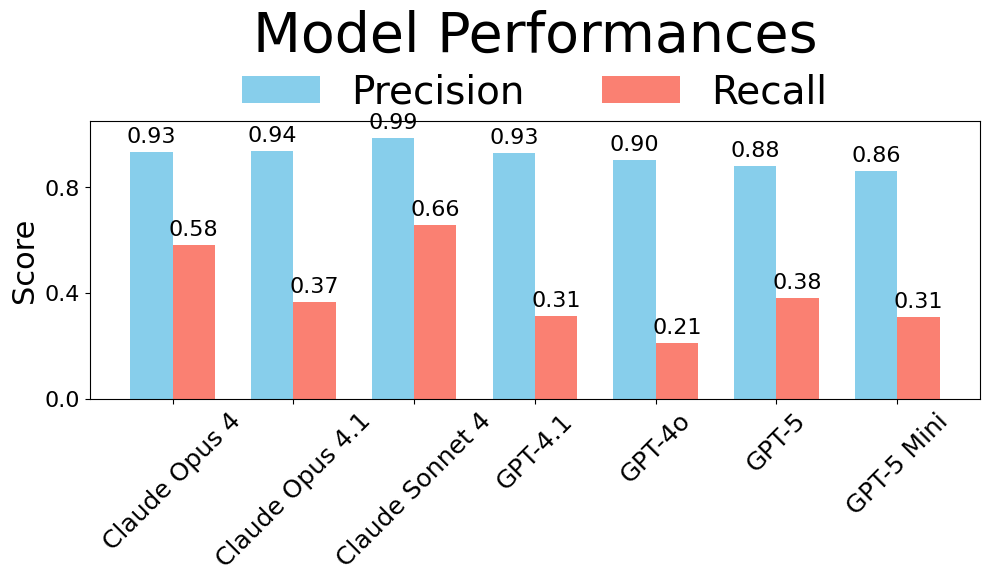

In [22]:
overall_performance_fig

#### Radar Plot: Recalls per field

##### Code

In [23]:
# ============================================================================
# RADAR PLOT: MODEL RECALLS PER FIELD (DATAFRAME VERSION)
# ============================================================================

# Convert to DataFrame and calculate recalls
df = metrics_to_dataframe(all_metrics)
df = add_field_categories(df)
df = calculate_metrics(df, metric_type='recall')

# Aggregate by model and category
aggregated = df.groupby(['model', 'category'])['score'].mean().reset_index()

# Pivot for radar plot
pivot_df = aggregated.pivot(index='model', columns='category', values='score').fillna(0)

# Create radar plot
fields = sorted(pivot_df.columns)
num_fields = len(fields)
angles = [n / float(num_fields) * 2 * pi for n in range(num_fields)]
angles += angles[:1]

radar_recall_fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Plot each model
for model_name in pivot_df.index:
    scores = pivot_df.loc[model_name, fields].tolist()
    values = scores + [scores[0]]
    line, = ax.plot(angles, values, label=model_name, linewidth=2)
    ax.fill(angles, values, color=line.get_color(), alpha=0.03)

# [Rest of plotting code remains the same...]
ax.set_ylim(0.0, 1)
angle_degrees = [a * 180 / np.pi for a in angles[:-1]]
ax.set_thetagrids(angle_degrees, labels=fields)
ax.tick_params(axis='x', pad=25)

for label in ax.get_xticklabels():
    label.set_fontsize(24)
    label.set_color("dimgray")
    label.set_rotation(45)
    label.set_horizontalalignment("center")

ax.set_yticks(np.linspace(0.0, 1, 3))
ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0.0, 1, 3)], 
                    fontsize=24, color="dimgray")

ax.set_theta_offset(np.deg2rad(17))
ax.set_theta_direction(-1)

plt.title("Model Recalls per Field", size=40, color="dimgray")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), 
           fontsize=24, ncol=2, frameon=False)
plt.tight_layout()
plt.close(radar_recall_fig)

##### Recall Plot

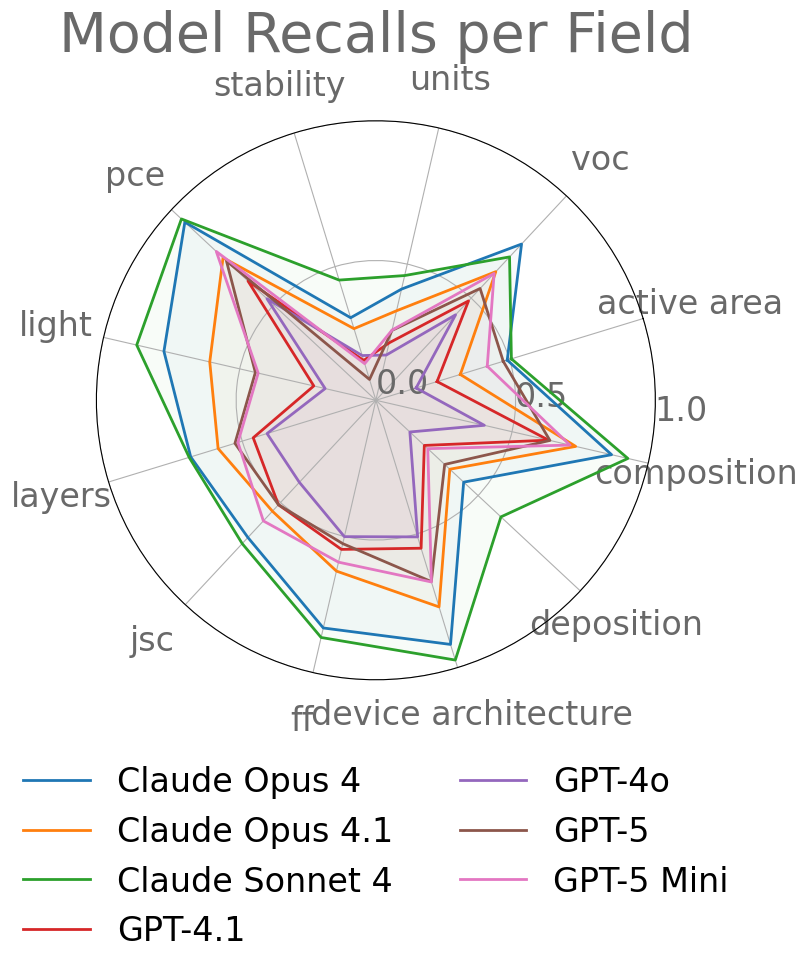

In [24]:
radar_recall_fig

#### Radar Plot: Precisions per field

##### Code

In [25]:
# ============================================================================
# RADAR PLOT: MODEL PRECISIONS PER FIELD (DATAFRAME VERSION)
# ============================================================================

# Convert to DataFrame and calculate precisions
df = metrics_to_dataframe(all_metrics)
df = add_field_categories(df)
df = calculate_metrics(df, metric_type='precision')  # Changed to precision

# Aggregate by model and category
aggregated = df.groupby(['model', 'category'])['score'].mean().reset_index()

# Pivot for radar plot
pivot_df = aggregated.pivot(index='model', columns='category', values='score').fillna(0)

# Create radar plot
fields = sorted(pivot_df.columns)
num_fields = len(fields)
angles = [n / float(num_fields) * 2 * pi for n in range(num_fields)]
angles += angles[:1]

radar_precision_fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Plot each model
for model_name in pivot_df.index:
    scores = pivot_df.loc[model_name, fields].tolist()
    values = scores + [scores[0]]
    line, = ax.plot(angles, values, label=model_name, linewidth=2)
    ax.fill(angles, values, color=line.get_color(), alpha=0.03)

# Customize plot
ax.set_ylim(0.3, 1)  # Different y-limit for precisions
angle_degrees = [a * 180 / np.pi for a in angles[:-1]]
ax.set_thetagrids(angle_degrees, labels=fields)
ax.tick_params(axis='x', pad=25)

# Style field labels
for label in ax.get_xticklabels():
    label.set_fontsize(24)
    label.set_color("dimgray")
    label.set_rotation(45)
    label.set_horizontalalignment("center")

# Style radial ticks
ax.set_yticks(np.linspace(0.3, 1, 3))
ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0.3, 1, 3)], 
                    fontsize=24, color="dimgray")

# Rotate plot
ax.set_theta_offset(np.deg2rad(17))
ax.set_theta_direction(-1)

# Title and legend
plt.title("Model Precisions per Field", size=40, color="dimgray")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=24,
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.close(radar_precision_fig)
# plt.savefig("plots/model_precisions_spider.pdf")

##### Plot

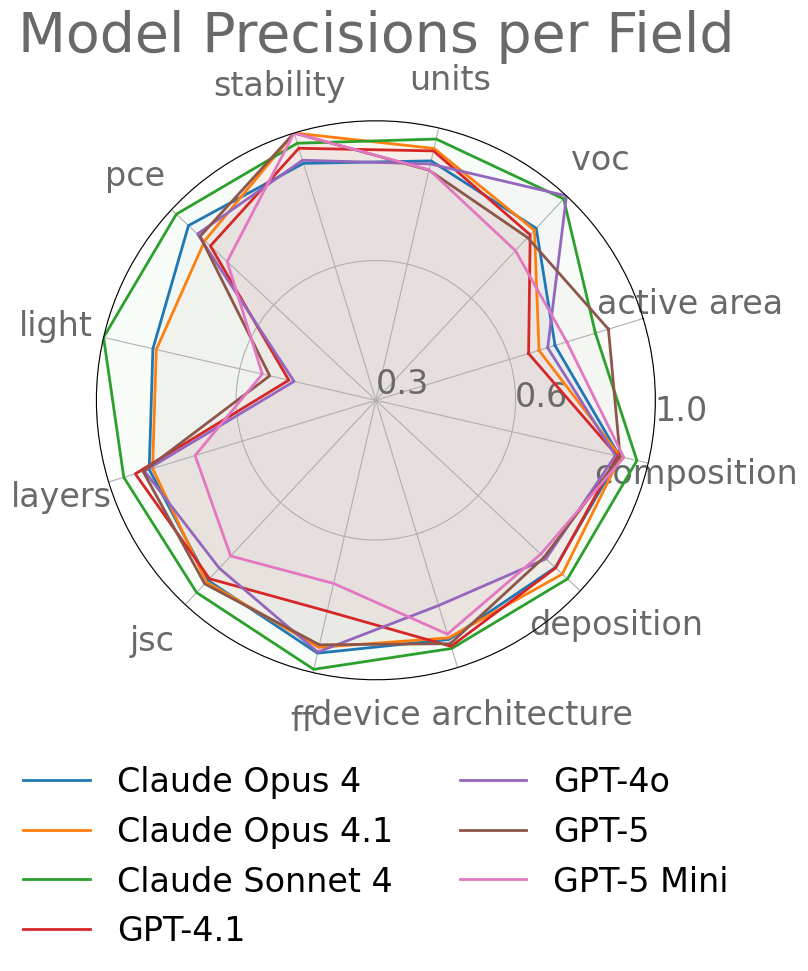

In [26]:
radar_precision_fig

### Visualize: Cost vs Performance

##### Code

In [28]:
# ============================================================================
# PLOTLY: MODEL PERFORMANCE VS COST
# ============================================================================

# Token usage and pricing data
tokens_used = {
    "GPT-5 Mini": {
        "Prompt Tokens": 883572,
        "Completion Tokens": 258233,
        "prompt_price": 0.250,
        "output_price": 2.0
    },
    "GPT-5": {
        "Prompt Tokens": 750932,
        "Completion Tokens": 260215,
        "prompt_price": 1.250,
        "output_price": 10.0
    },
    "Claude Opus 4.1": {
        "Prompt Tokens": 695811,
        "Completion Tokens": 128001,
        "prompt_price": 15.0,
        "output_price": 75.0
    },
    "Claude Opus 4": {
        "Prompt Tokens": 1000308,
        "Completion Tokens": 230768,
        "prompt_price": 15.0,
        "output_price": 75.0
    },
    "Claude Sonnet 4": {
        "Prompt Tokens": 889990,
        "Completion Tokens": 174639,
        "prompt_price": 3.0,
        "output_price": 15.0
    },
    "GPT-4.1": {
        "Prompt Tokens": 750680,
        "Completion Tokens": 54524,
        "prompt_price": 2.0,
        "output_price": 8.0
    },
    "GPT-4o": {
        "Prompt Tokens": 677364,
        "Completion Tokens": 28682,
        "prompt_price": 2.50,
        "output_price": 10.0
    },
}

# Calculate costs and merge with performance metrics
cost_data = []
for model, tokens in tokens_used.items():
    prompt_tokens = tokens["Prompt Tokens"]
    completion_tokens = tokens["Completion Tokens"]
    prompt_price = tokens["prompt_price"]
    output_price = tokens["output_price"]
    total_cost = (prompt_tokens / 1_000_000) * prompt_price + (completion_tokens / 1_000_000) * output_price
    
    cost_data.append({
        "model": model,
        "cost": round(total_cost, 4)
    })

# Create cost DataFrame
df_cost = pd.DataFrame(cost_data)

# Merge with the overall performance metrics (from the bar chart section)
# Assuming 'overall' DataFrame exists from the previous bar chart code
df_plot = overall.merge(df_cost, on='model', how='inner')

# Calculate F1 score
df_plot['f1'] = (2 * df_plot['precision'] * df_plot['recall']) / (df_plot['precision'] + df_plot['recall'])
df_plot = df_plot.dropna(subset=['f1'])


# Color palette
MODEL_COLORS = [
    '#1f77b4',  # Muted Blue
    '#ff7f0e',  # Orange
    '#2ca02c',  # Green
    '#d62728',  # Red
    '#9467bd',  # Purple
    '#8c564b',  # Brown
    '#e377c2',  # Pink
]

# Create Plotly figure
perf_cost_fig = go.Figure()

for index, row in df_plot.iterrows():
    model = row['model']
    cost = row['cost']
    f1 = row['f1']
    
    color = MODEL_COLORS[index % len(MODEL_COLORS)]

    # Scatter trace for marker
    perf_cost_fig.add_trace(
        go.Scatter(
            x=[cost],
            y=[f1],
            mode='markers',
            name=model, 
            marker=dict(
                size=15,
                opacity=0.8,
                color=color
            ),
            hovertemplate='<b>%{text}</b><br>Cost: $%{x:.4f}<br>F1 Score: %{y:.4f}<extra></extra>',
            text=[model]
        )
    )

    # Text trace for label
    perf_cost_fig.add_trace(
        go.Scatter(
            x=[cost],
            y=[f1-0.014],
            mode='text',
            name=model + ' Label', 
            text=[model],
            textposition='bottom center',
            showlegend=False,
            textfont=dict(size=14, color=color),
            hoverinfo='none'
        )
    )

# Layout
perf_cost_fig.update_layout(
    title={
        'text': "Model Performance vs Cost",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Total Cost (USD)",
    yaxis_title="F1 Score",
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02,
        bgcolor="rgba(255, 255, 255, 0.5)",
        bordercolor="Black",
        borderwidth=1
    )
)

perf_cost_fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(128,128,128,0.5)')
perf_cost_fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='rgba(128,128,128,0.5)')

pass

##### Plot

In [29]:
perf_cost_fig.show()

### Comparison with Experts

#### Evaluation Code

In [34]:
pipeline = ExtractionPipeline(model_name="experts", preprocessor="pymupdf", postprocessor="NONE", cache_dir="", use_cache=True)
authors_metrics, authors_recalls, authors_precisions = pipeline._evaluate_multiple(EXPERTS_DIR, GROUND_TRUTH_DIR)

Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/consensus/10.1038--s41467-021-27740-4.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/consensus/10.1002--solr.202300817.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/consensus/10.1126--science.adf0194.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/consensus/10.1021--acsaelm.4c02297.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/consensus/10.1038--s41467-023-36141-8.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/

In [35]:
all_metrics["experts"] = authors_metrics
experts_included_df = metrics_to_dataframe(all_metrics)

# 1. Get the set of papers that appear with model == "experts"
expert_papers = set(experts_included_df.loc[
    experts_included_df["model"] == "experts", 
    "paper"
])

# 2. Filter the DataFrame
filtered_df = experts_included_df[
    (experts_included_df["model"] == "experts") |
    ((experts_included_df["model"] != "experts") &
     (experts_included_df["paper"].isin(expert_papers)))
]

In [36]:
# Group by paper and model, sum TP and FP
micro_precision_df = (
    filtered_df
    .groupby(['paper', 'model'])
    [['TP', 'FP']]
    .sum()
    .reset_index()
)

# Compute micro-precision
micro_precision_df['precision'] = micro_precision_df['TP'] / (micro_precision_df['TP'] + micro_precision_df['FP'])


In [ ]:
# Only select the papers where both LLMs and experts exist
papers_with_both = micro_precision_df['paper'].value_counts()
papers_with_both = papers_with_both[papers_with_both > 1].index
df_plot = micro_precision_df[micro_precision_df['paper'].isin(papers_with_both)]

# Pivot data so each row is a DOI and each column is a model
df_pivot = df_plot.pivot(index='paper', columns='model', values='precision').reset_index()

# Melt data for dabest
df_melt = df_pivot.melt(id_vars='paper', var_name='model', value_name='precision')

# Create a dabest object using authors as the control
dabest_data = dabest.load(
    data=df_melt,
    x='model',
    y='precision',
    idx=("experts", "GPT-4.1", "Claude Opus 4", "GPT-4o", "GPT-5",
         "Claude Sonnet 4", "Claude Opus 4.1", "GPT-5 Mini")
)

# Plot mean difference against authors
plt.figure(figsize=(10,6))
mean_fig = dabest_data.mean_diff.plot(raw_marker_size=4)
plt.close(mean_fig)

<Figure size 1000x600 with 0 Axes>

#### Mean Difference per paper

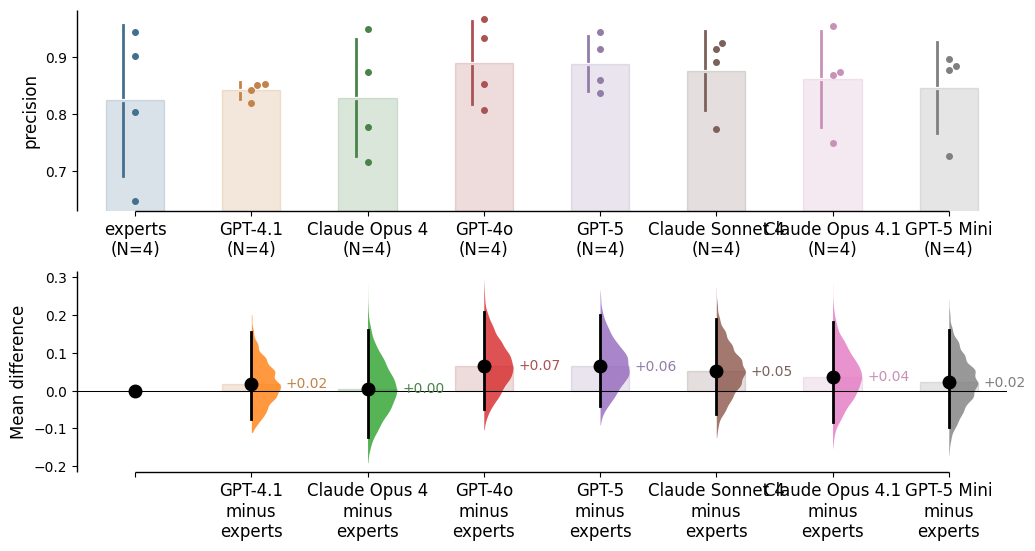

In [38]:
mean_fig

#### Overlapping extractions spider plots

In [61]:
# ============================================================================
# DATA LOADING AND MODEL EVALUATION
# ============================================================================

human_metrics = {}  # model_name -> paper_doi -> {field: score}
human_precs_and_recalls = {}

HUMANS_DIR = EXTRACTIONS_DIR / "humans"
# Evaluate all models
for model_dir in HUMANS_DIR.iterdir():
    if not model_dir.is_dir():
        continue
    
    model_name = model_dir.name
    print(f"Evaluating model: {model_name}")
    
    pipeline = ExtractionPipeline(
        model_name=model_name, 
        preprocessor="pymupdf", 
        postprocessor="NONE", 
        cache_dir="", 
        use_cache=True
    )
    model_metrics, avg_recalls, avg_precisions = pipeline._evaluate_multiple(
        model_dir, GROUND_TRUTH_DIR
    )
    
    human_precs_and_recalls[model_name] = {
        "precision": avg_precisions, 
        "recall": avg_recalls
    }
    human_metrics[model_name] = model_metrics

# Non-human addition
sonnet_4_overlap_metrics = {
    doi: value
    for doi, value in all_metrics["Claude Sonnet 4"].items()
    if doi in human_metrics["Consensus"]
}
human_metrics["Sonnet 4"] = sonnet_4_overlap_metrics

Evaluating model: Consensus
Error converting 5 wt%: 'wt' is not defined in the unit registry
Error converting 5 wt%: 'wt' is not defined in the unit registry
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/Consensus/10.1038--s41467-021-27740-4.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/Consensus/10.1002--solr.202300817.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/Consensus/10.1126--science.adf0194.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/Consensus/10.1021--acsaelm.4c02297.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite-extraction/src/perovscribe/data/extractions/humans/Consensus/10.1038--s41467-023-36141-8.json'
[Errno 2] No such file or directory: '/home/me/Work/perovskite

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:313: RuntimeWarning:

Mean of empty slice

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:314: RuntimeWarning:

Mean of empty slice

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:316: RuntimeWarning:

Mean of empty slice

/home/me/Work/perovskite-extraction/src/perovscribe/pipeline.py:317: RuntimeWarning:

Mean of empty slice



Mismatch for perovskite_composition:formula: truth='(FAPbI3)0.95(MAPbBr3)0.05' vs extraction=''
Mismatch for light_source:description: truth='None' vs extraction='Newport, Oriel Sol3A Class AAA'
LLM judge for layers:0:name: ITO/glass vs ITO -> True
LLM judge for layers:0:functionality: Substrate vs Contact -> False
Stack: ['ITO/glass', 'SnO2', '(FAPbI3)0.95(MAPbBr3)0.05', 'Spiro-OMeTAD', 'Au']
Mismatch for layers:0:functionality: truth='Substrate' vs extraction='Contact'
LLM judge for perovskite_composition:formula: (FAPbI3)0.95(MAPbBr3)0.05 vs FA0.95MA0.05PbI2.85Br0.15 -> True
LLM judge for perovskite_composition:a_ions:0:molecular_formula: CH6N+ vs CH5N2+ -> False
Mismatch for perovskite_composition:a_ions:0:molecular_formula: truth='CH6N+' vs extraction='CH5N2+'
LLM judge for perovskite_composition:a_ions:1:molecular_formula: CH5N+ vs CH6N+ -> False
Mismatch for perovskite_composition:a_ions:1:molecular_formula: truth='CH5N+' vs extraction='CH6N+'
Mismatch for number_devices: truth=

##### What dois match across our extractions for these 4 overlapping ones

In [65]:
from collections import defaultdict

doi_to_groups = defaultdict(list)

for group, dois in human_metrics.items():
    for doi in dois:
        doi_to_groups[doi].append(group)

print("DOI matches across groups:\n")
for doi, groups in doi_to_groups.items():
    if len(groups) > 1:
        print(f"{doi} -> {', '.join(groups)}")


DOI matches across groups:

10.1039--c5ta00568j.json -> Consensus, Otto, Kit, Robin, Sonnet 4
10.1002--adfm.202212698.json -> Consensus, Fox, Kit, Lark, Seal, Hawk, Sonnet 4
10.1016--j.nanoen.2022.107416.json -> Consensus, Otto, Fox, Lark, Dove, Hawk, Sonnet 4
10.1002--solr.202100879.json -> Consensus, Bear, Lark, Bee, Hawk, Sonnet 4


In [66]:
pivot_df

category,active area,composition,deposition,device architecture,ff,jsc,layers,light,pce,stability,units,voc
model,,,,,,,,,,,,
Bear,1.0,1.000000,1.000000,1.00,1.000000,1.000000,0.866667,1.0,1.000000,1.000000,1.000000,1.000000
Bee,0.0,0.750000,0.000000,1.00,0.000000,0.000000,0.000000,1.0,0.000000,1.000000,1.000000,0.000000
Consensus,1.0,0.800000,0.812500,1.00,0.500000,0.500000,0.807407,0.8,0.750000,0.333333,1.000000,0.583333
Dove,1.0,1.000000,0.000000,1.00,1.000000,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.000000
Fox,1.0,0.000000,1.000000,1.00,0.833333,0.833333,0.866667,1.0,0.833333,0.500000,1.000000,0.833333
Hawk,1.0,0.933333,1.000000,1.00,0.833333,0.833333,0.850000,0.6,0.833333,1.000000,1.000000,0.833333
Kit,1.0,0.000000,1.000000,1.00,0.000000,0.000000,0.946667,1.0,0.500000,0.000000,1.000000,0.166667
Lark,1.0,1.000000,0.916667,1.00,1.000000,1.000000,0.866667,1.0,1.000000,0.333333,1.000000,1.000000
Otto,1.0,0.500000,0.750000,1.00,0.500000,0.500000,0.766667,0.5,1.000000,1.000000,1.000000,0.500000


In [71]:
# ============================================================================
# RADAR PLOT: MODEL PRECISIONS PER FIELD (DATAFRAME VERSION)
# ============================================================================

# Convert to DataFrame and calculate precisions
df = metrics_to_dataframe(human_metrics)
df = add_field_categories(df)
df = calculate_metrics(df, metric_type='precision')  # Changed to precision

# Aggregate by model and category
aggregated = df.groupby(['model', 'category'])['score'].mean().reset_index()

# Pivot for radar plot
pivot_df = aggregated.pivot(index='model', columns='category', values='score').fillna(0)

# Create radar plot
fields = sorted(pivot_df.columns)
num_fields = len(fields)
angles = [n / float(num_fields) * 2 * pi for n in range(num_fields)]
angles += angles[:1]

human_radar_precision_fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# 1. Define a color palette for all models (ensuring different colors)
# We use a set of distinct colors and map them to models.
# Matplotlib's 'tab20' is a good choice for up to 20 distinct colors.
num_models = len(pivot_df.index)
colors = plt.cm.get_cmap('tab20', max(num_models, 1)) # Use 'tab20' for distinct colors
model_to_color = {model: colors(i) for i, model in enumerate(pivot_df.index)}

# Plot each model
for model_name in pivot_df.index:
    scores = pivot_df.loc[model_name, fields].tolist()
    values = scores + [scores[0]]
    
    # 2. Set distinct color for the line
    line_color = model_to_color[model_name]
    
    # 3. Control visibility and emphasis
    if model_name in ('Consensus', 'Sonnet 4'):
        # Highlight: Bright color, thicker line, higher alpha fill
        line_alpha = 1.0  # Full opacity for the line
        fill_alpha = 0.05  # Moderate fill opacity
        line_width = 4    # Thicker line
    else:
        # Dimmer: Lower opacity for line and fill, normal line width
        line_alpha = 0.3  # Dimmed opacity
        fill_alpha = 0.02 # Very light fill
        line_width = 2    # Normal line width

    line, = ax.plot(
        angles, 
        values, 
        label=model_name, 
        linewidth=line_width,
        color=line_color,  # Apply the unique color
        alpha=line_alpha   # Apply the line opacity
    )
    
    ax.fill(
        angles, 
        values, 
        color=line_color,  # Apply the unique color
        alpha=fill_alpha   # Apply the fill opacity
    )

# Customize plot (Rest of the customization remains the same)
ax.set_ylim(0.3, 1)  # Different y-limit for precisions
angle_degrees = [a * 180 / np.pi for a in angles[:-1]]
ax.set_thetagrids(angle_degrees, labels=fields)
ax.tick_params(axis='x', pad=25)

# Style field labels
for label in ax.get_xticklabels():
    label.set_fontsize(24)
    label.set_color("dimgray")
    label.set_rotation(45)
    label.set_horizontalalignment("center")

# Style radial ticks
ax.set_yticks(np.linspace(0.0, 1, 3))
ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0.0, 1, 3)], 
                    fontsize=24, color="dimgray")

# Rotate plot
ax.set_theta_offset(np.deg2rad(17))
ax.set_theta_direction(-1)

# Title and legend
plt.title("Model Precisions per Field", size=40, color="dimgray")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=24,
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.close(human_radar_precision_fig)

/tmp/ipykernel_25324/3427354200.py:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



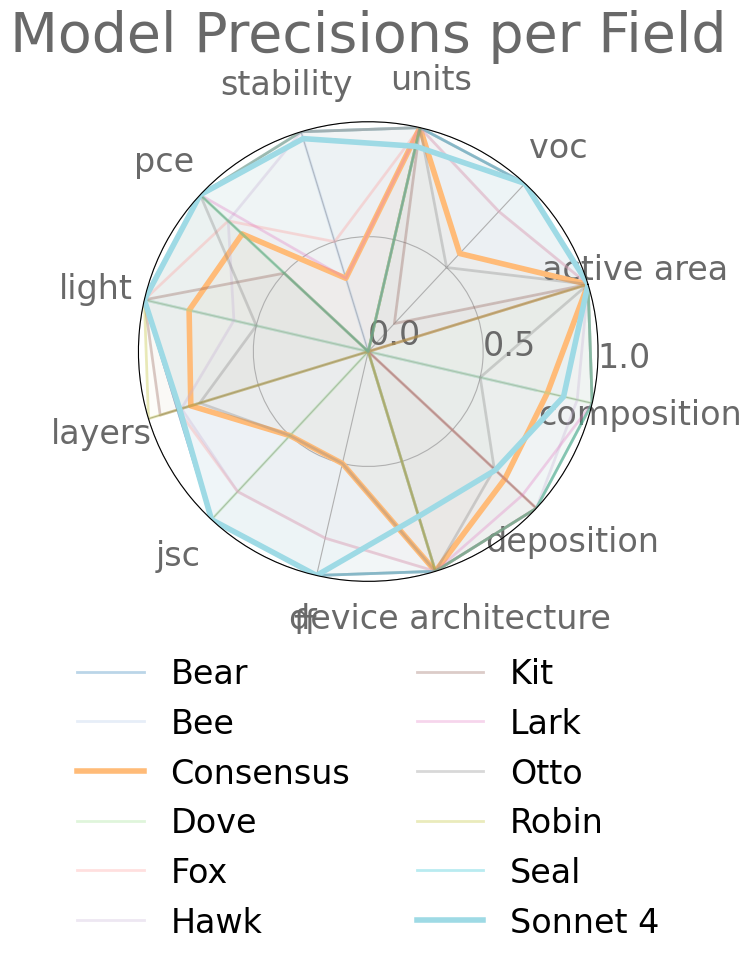

In [72]:
human_radar_precision_fig

##### Another look with the DEV set

In [48]:
# ============================================================================
# DATA LOADING AND MODEL EVALUATION
# ============================================================================

human_metrics = {}  # model_name -> paper_doi -> {field: score}
human_precs_and_recalls = {}

HUMANS_DIR = EXTRACTIONS_DIR / "humans"
DEV_DIR = DATA_DIR / "ground_truth" / "dev"
# Evaluate all models
for model_dir in HUMANS_DIR.iterdir():
    if not model_dir.is_dir():
        continue
    
    model_name = model_dir.name
    print(f"Evaluating model: {model_name}")
    
    pipeline = ExtractionPipeline(
        model_name=model_name, 
        preprocessor="pymupdf", 
        postprocessor="NONE", 
        cache_dir="", 
        use_cache=True
    )
    model_metrics, avg_recalls, avg_precisions = pipeline._evaluate_multiple(
        model_dir, DEV_DIR
    )
    
    human_precs_and_recalls[model_name] = {
        "precision": avg_precisions, 
        "recall": avg_recalls
    }
    human_metrics[model_name] = model_metrics

Evaluating model: Consensus
Error converting 35.0 wt%: 'wt' is not defined in the unit registry
Error converting 35.0 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 22 wt%: 'wt' is not defined in the unit registry
Error converting 14.3 wt%: 'wt' is not defined in the unit registry
Error converting 14.3 wt%: 'wt' is not defined in the unit registry
Error converting 14.3 wt%: 'wt' is not defined in the unit registry
Error converting 14.3 wt%: 'wt' is not defined in the unit registry
Processing file: 10.1016--j.nanoen.2016.05.023.json
LLM judge for layers:1:deposition:0:atmosphere: Ambient Air vs Air -> True
LLM judge for layers:2:deposition:0:atmosphere: Ambient Air vs Air -> True
LLM judge for layers:3:depositio

In [49]:
# ============================================================================
# RADAR PLOT: MODEL PRECISIONS PER FIELD (DATAFRAME VERSION)
# ============================================================================

# Convert to DataFrame and calculate precisions
df = metrics_to_dataframe(human_metrics)
df = add_field_categories(df)
df = calculate_metrics(df, metric_type='precision')  # Changed to precision

# Aggregate by model and category
aggregated = df.groupby(['model', 'category'])['score'].mean().reset_index()

# Pivot for radar plot
pivot_df = aggregated.pivot(index='model', columns='category', values='score').fillna(0)

# Create radar plot
fields = sorted(pivot_df.columns)
num_fields = len(fields)
angles = [n / float(num_fields) * 2 * pi for n in range(num_fields)]
angles += angles[:1]

human_radar_precision_fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# 1. Define a color palette for all models (ensuring different colors)
# We use a set of distinct colors and map them to models.
# Matplotlib's 'tab20' is a good choice for up to 20 distinct colors.
num_models = len(pivot_df.index)
colors = plt.cm.get_cmap('tab20', max(num_models, 1)) # Use 'tab20' for distinct colors
model_to_color = {model: colors(i) for i, model in enumerate(pivot_df.index)}

# Plot each model
for model_name in pivot_df.index:
    scores = pivot_df.loc[model_name, fields].tolist()
    values = scores + [scores[0]]
    
    # 2. Set distinct color for the line
    line_color = model_to_color[model_name]
    
    # 3. Control visibility and emphasis
    if model_name == 'Consensus':
        # Highlight: Bright color, thicker line, higher alpha fill
        line_alpha = 1.0  # Full opacity for the line
        fill_alpha = 0.2  # Moderate fill opacity
        line_width = 4    # Thicker line
    else:
        # Dimmer: Lower opacity for line and fill, normal line width
        line_alpha = 0.3  # Dimmed opacity
        fill_alpha = 0.02 # Very light fill
        line_width = 2    # Normal line width

    line, = ax.plot(
        angles, 
        values, 
        label=model_name, 
        linewidth=line_width,
        color=line_color,  # Apply the unique color
        alpha=line_alpha   # Apply the line opacity
    )
    
    ax.fill(
        angles, 
        values, 
        color=line_color,  # Apply the unique color
        alpha=fill_alpha   # Apply the fill opacity
    )

# Customize plot (Rest of the customization remains the same)
ax.set_ylim(0.3, 1)  # Different y-limit for precisions
angle_degrees = [a * 180 / np.pi for a in angles[:-1]]
ax.set_thetagrids(angle_degrees, labels=fields)
ax.tick_params(axis='x', pad=25)

# Style field labels
for label in ax.get_xticklabels():
    label.set_fontsize(24)
    label.set_color("dimgray")
    label.set_rotation(45)
    label.set_horizontalalignment("center")

# Style radial ticks
ax.set_yticks(np.linspace(0.3, 1, 3))
ax.set_yticklabels([f"{y:.1f}" for y in np.linspace(0.3, 1, 3)], 
                    fontsize=24, color="dimgray")

# Rotate plot
ax.set_theta_offset(np.deg2rad(17))
ax.set_theta_direction(-1)

# Title and legend
plt.title("Model Precisions per Field", size=40, color="dimgray")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=24,
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.close(human_radar_precision_fig)

/tmp/ipykernel_25324/590563995.py:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



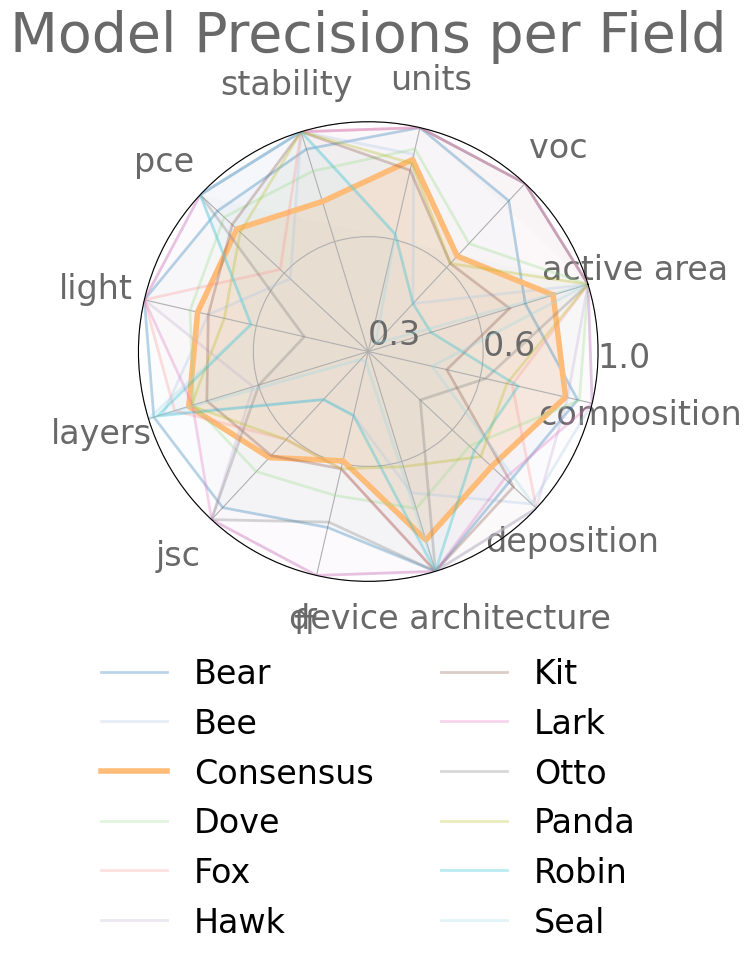

In [50]:
human_radar_precision_fig